# light GBM 모델

In [6]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report
from lightgbm import LGBMClassifier

import hanwoo_pipeline as hp


# 데이터 위치
BASE = Path(r"C:\Users\pc\Downloads\contest_data_2\hanwoo")

TARGET = "LAST_GRADE"


# 원본 데이터 로드


print("데이터 로딩")

train_df = hp.read_csv_safe(
    BASE / "hanwoo_train.csv"
)

test_df = hp.read_csv_safe(
    BASE / "test_hanwoo.csv"
)

area_df = hp.read_csv_safe(
    BASE / "hanwoo_area.csv"
)

death_df = hp.read_csv_safe(
    BASE / "hanwoo_death.csv"
)

lineage_df = hp.read_csv_safe(
    BASE / "hanwoo_lineage.csv",
    usecols=["CATTLE_NO", "KPN_NO"]
)

weather_df = hp.read_csv_safe(
    BASE / "hanwoo_weather.csv"
)

print("train :", train_df.shape)
print("test  :", test_df.shape)


# 제출용 Feature 생성
# test_hanwoo.csv 에 존재하는 정보만 사용


print("\n제출용 Feature 생성 중...")

parts, numeric_features, categorical_features = hp.build_submission_frame(
    train_df=train_df,
    test_df=test_df,
    weather_df=weather_df,
    area_df=area_df,
    death_df=death_df,
    lineage_df=lineage_df,
    windows=(30, 90, 180),
    target=TARGET
)

features = numeric_features + categorical_features

print("\n사용 Feature 수 :", len(features))
print("Numeric :", len(numeric_features))
print("Categorical :", len(categorical_features))


# LightGBM 모델


def build_model():

    preprocess = hp.build_ordinal_preprocess(
        numeric_features,
        categorical_features
    )

    model = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    return Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])


# 내부 검증


print("\n내부 검증 시작")

X = parts["train"][features]
y = parts["train"][TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = build_model()

model.fit(
    X_train,
    y_train
)

valid_pred = model.predict(X_valid)

macro_f1 = f1_score(
    y_valid,
    valid_pred,
    average="macro"
)

print(f"\nMacro-F1 : {macro_f1:.4f}")

report = pd.DataFrame(
    classification_report(
        y_valid,
        valid_pred,
        output_dict=True,
        zero_division=0
    )
).T

print(
    report[
        ["precision", "recall", "f1-score", "support"]
    ].round(3)
)


# 전체 데이터 재학습


print("\n전체 데이터 재학습")

final_model = build_model()

final_model.fit(
    X,
    y
)


# test_hanwoo 예측

print("\n예측 중...")

test_pred = final_model.predict(
    parts["test"][features]
)


# 제출 파일 생성

submission = test_df.copy()

submission[TARGET] = test_pred

save_path = BASE / "submission_lightgbm.csv"

submission.to_csv(
    save_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n저장 완료")
print(save_path)

print("\n예측 분포")
print(
    submission[TARGET]
    .value_counts()
    .sort_index()
)

데이터 로딩 중...
train : (2408699, 23)
test  : (452497, 13)

제출용 Feature 생성 중...

사용 Feature 수 : 56
Numeric : 50
Categorical : 6

내부 검증 시작

Macro-F1 : 0.2087
              precision  recall  f1-score    support
1++A              0.227   0.331     0.269   41405.00
1++B              0.273   0.168     0.208   63918.00
1++C              0.171   0.425     0.244   25799.00
1+A               0.141   0.175     0.156   33449.00
1+B               0.198   0.050     0.079   62245.00
1+C               0.115   0.116     0.116   26019.00
1A                0.157   0.138     0.147   33635.00
1B                0.201   0.033     0.056   59858.00
1C                0.100   0.108     0.104   23395.00
2A                0.165   0.340     0.222   25482.00
2B                0.197   0.100     0.132   39173.00
2C                0.068   0.192     0.101   12588.00
3A                0.194   0.514     0.281    9443.00
3B                0.482   0.399     0.437   19515.00
3C                0.103   0.427     0.166    4708.00

# 등급 분포

C:\Users\pc\.matplotlib


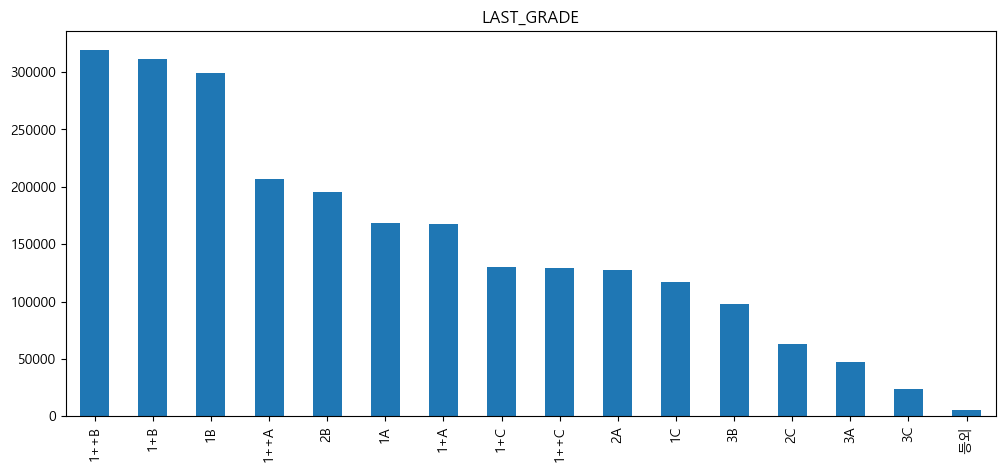

In [30]:
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(matplotlib.get_configdir())

import matplotlib.pyplot as plt

grade_counts = train_df["LAST_GRADE"].value_counts()

plt.figure(figsize=(12,5))
grade_counts.plot(kind="bar")

plt.title("LAST_GRADE")
plt.xlabel("")
plt.ylabel("")

plt.show()

# 개월수별 평균 육량지수

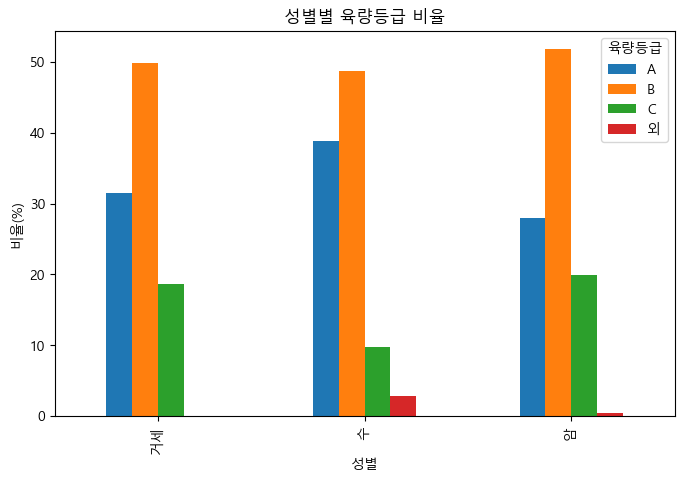

In [31]:
yield_by_sex = pd.crosstab(
    eda["JUDGE_SEX"],
    eda["YIELD_GRADE"],
    normalize="index"
) * 100

yield_by_sex.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("성별별 육량등급 비율")
plt.ylabel("비율(%)")
plt.xlabel("성별")
plt.legend(title="육량등급")
plt.show()

# 개월수별 육량등급 분포

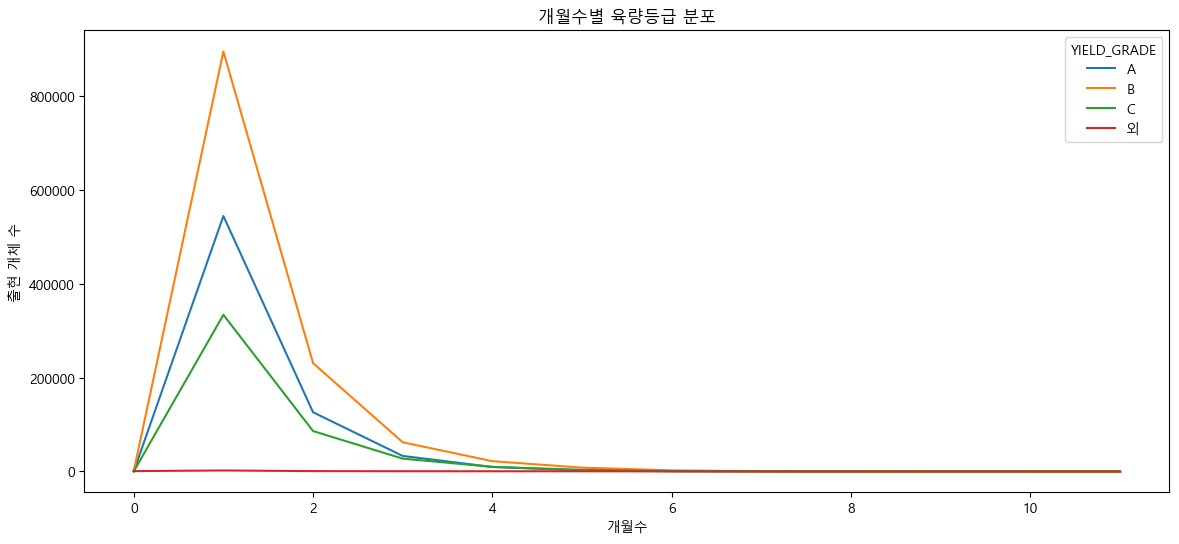

In [32]:
eda["YIELD_GRADE"] = (
    eda["LAST_GRADE"]
    .astype(str)
    .str[-1]
)

grade_age = (
    eda.groupby(["AGE_MONTH","YIELD_GRADE"])
    .size()
    .unstack(fill_value=0)
)

grade_age.plot(
    figsize=(14,6)
)

plt.title("개월수별 육량등급 분포")
plt.xlabel("개월수")
plt.ylabel("출현 개체 수")

plt.show()

# 중요 예측변수 그래프

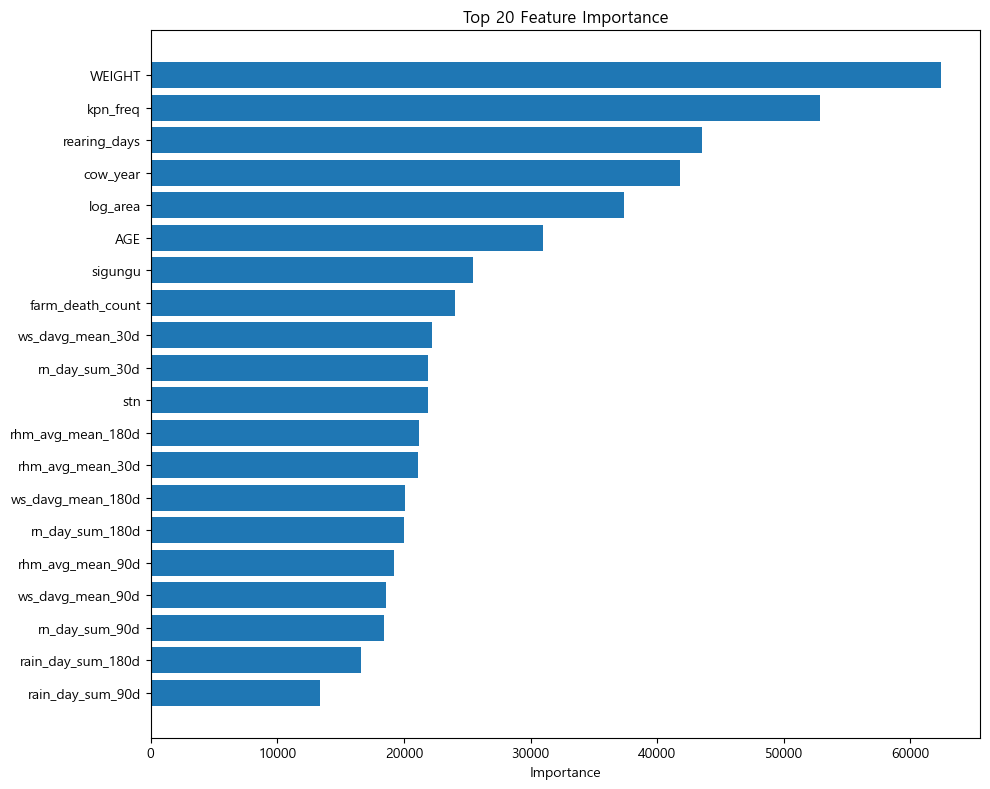

In [33]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["feature"][::-1],
    top20["importance"][::-1]
)

plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()